# Company Spotlight: セプテーニ HD & ビジネスコーチの「理想的人的資本指標」

本ノートブックでは、ユーザの所属/前職 2 社について人的資本指標 3 つ
（女性管理職比率・男性育休取得率・男女賃金格差）の「理想値」を半分冗談込みで推定します。

**前提と注意**:
- セプテーニ HD は **持株会社** のため、提出会社単体の HC 指標はほぼ NULL。「連結子会社 (= グループ全体)」の値で評価します。
- ビジネスコーチは **従業員 58 名** の極小規模。n=1〜2 の値を真に受けると統計ノイズに振り回されます。
- 業界比較は EDINETコード集約一覧 (`Edinetcode.zip`) の取り込みが前提。未取得時は規模 peer だけで進めます。


In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
# 日本語フォント設定（macOS 標準）。sns.set_style の後に置かないと
# rcParams['font.family'] が ['sans-serif'] にリセットされてしまう。
plt.rcParams['font.family'] = ['Hiragino Sans']
plt.rcParams['axes.unicode_minus'] = False

DB_PATH = '../artifacts/analytics/edinet_analytics.duckdb'
conn = duckdb.connect(DB_PATH, read_only=True)

SEPTENI = 'E05206'
BCOACH = 'E37957'
TARGETS = [SEPTENI, BCOACH]

HC_COLS = ['female_manager_ratio', 'male_childcare_leave_ratio', 'gender_wage_gap']
HC_LABELS = {
    'female_manager_ratio': '女性管理職比率',
    'male_childcare_leave_ratio': '男性育休取得率',
    'gender_wage_gap': '男女賃金格差',
}

print('DuckDB:', DB_PATH)

DuckDB: ../artifacts/analytics/edinet_analytics.duckdb


## 1. データ取得と 2 社プロファイル

In [2]:
profile = conn.execute(
    """
    SELECT edinet_code, company_name, industry, fiscal_year, scope, worker_type,
           sales, operating_profit, employee_count,
           female_manager_ratio, male_childcare_leave_ratio, gender_wage_gap
      FROM analytics.company_year_metrics
     WHERE edinet_code IN (?, ?)
     ORDER BY edinet_code, fiscal_year DESC, scope, worker_type
    """,
    [SEPTENI, BCOACH],
).fetchdf()
profile

,edinet_code,company_name,industry,fiscal_year,scope,worker_type,sales,operating_profit,employee_count,female_manager_ratio,male_childcare_leave_ratio,gender_wage_gap
0,E05206,株式会社セプテーニ・ホールディングス,サービス業,2024,consolidated_subsidiary,all,28284209000,3129260000,1800,26.4,NaN,79.00
1,E05206,株式会社セプテーニ・ホールディングス,サービス業,2024,consolidated_subsidiary,non_regular,28284209000,3129260000,1800,NaN,NaN,49.10
2,E05206,株式会社セプテーニ・ホールディングス,サービス業,2024,consolidated_subsidiary,regular,28284209000,3129260000,1800,NaN,NaN,82.85
3,E05206,株式会社セプテーニ・ホールディングス,サービス業,2024,reporting_company,all,28284209000,3129260000,1800,NaN,NaN,2.30
4,E05206,株式会社セプテーニ・ホールディングス,サービス業,2023,reporting_company,all,34266611000,4949134000,1735,NaN,NaN,3.00
5,E37957,ビジネスコーチ株式会社,サービス業,2025,reporting_company,all,2003993000,163845000,59,20.0,3.3,77.30
6,E37957,ビジネスコーチ株式会社,サービス業,2025,reporting_company,regular,2003993000,163845000,59,NaN,NaN,77.30
7,E37957,ビジネスコーチ株式会社,サービス業,2024,consolidated_subsidiary,all,1601091000,79888000,58,0.0,0.0,97.20
8,E37957,ビジネスコーチ株式会社,サービス業,2024,consolidated_subsidiary,non_regular,1601091000,79888000,58,NaN,0.0,NaN
9,E37957,ビジネスコーチ株式会社,サービス業,2024,consolidated_subsidiary,regular,1601091000,79888000,58,NaN,0.0,97.20


## 2. 評価次元の宣言（重要）

- **セプテーニ HD**: 提出会社単体には HC 指標がほぼ NULL → `scope='consolidated_subsidiary'` × `worker_type='all'` で評価（グループ全体の代表値）。
- **ビジネスコーチ**: 単体で HC 指標が揃っている → `scope='reporting_company'` × `worker_type='all'` で評価。

両社で評価する `scope` が違うため、**直接の数値比較は本質的にアンフェア**。同じ scope の peer 群と比べることに意味があり、両社間の直接比較は半分冗談として扱います。

In [3]:
FY = 2024  # 直近年度に固定（両社とも 2024 年度のデータあり）

septeni_row = profile[
    (profile['edinet_code'] == SEPTENI)
    & (profile['fiscal_year'] == FY)
    & (profile['scope'] == 'consolidated_subsidiary')
    & (profile['worker_type'] == 'all')
].iloc[0]

bcoach_row = profile[
    (profile['edinet_code'] == BCOACH)
    & (profile['fiscal_year'] == FY)
    & (profile['scope'] == 'reporting_company')
    & (profile['worker_type'] == 'all')
].iloc[0]

summary = pd.DataFrame({
    'セプテーニ HD (連結)': septeni_row[HC_COLS + ['employee_count', 'sales']],
    'ビジネスコーチ (単体)': bcoach_row[HC_COLS + ['employee_count', 'sales']],
})
summary

,セプテーニ HD (連結),ビジネスコーチ (単体)
female_manager_ratio,26.4,25.0
male_childcare_leave_ratio,NaN,0.0
gender_wage_gap,79.0,67.1
employee_count,1800,58
sales,28284209000,1601091000


## 3. 全企業分布における位置

まずは「全企業 × `scope × worker_type` 固定」の分布で 2 社がどこにいるかを確認します。

reporting_company × all (FY2024): n=4213
consolidated_subsidiary × all (FY2024): n=1487


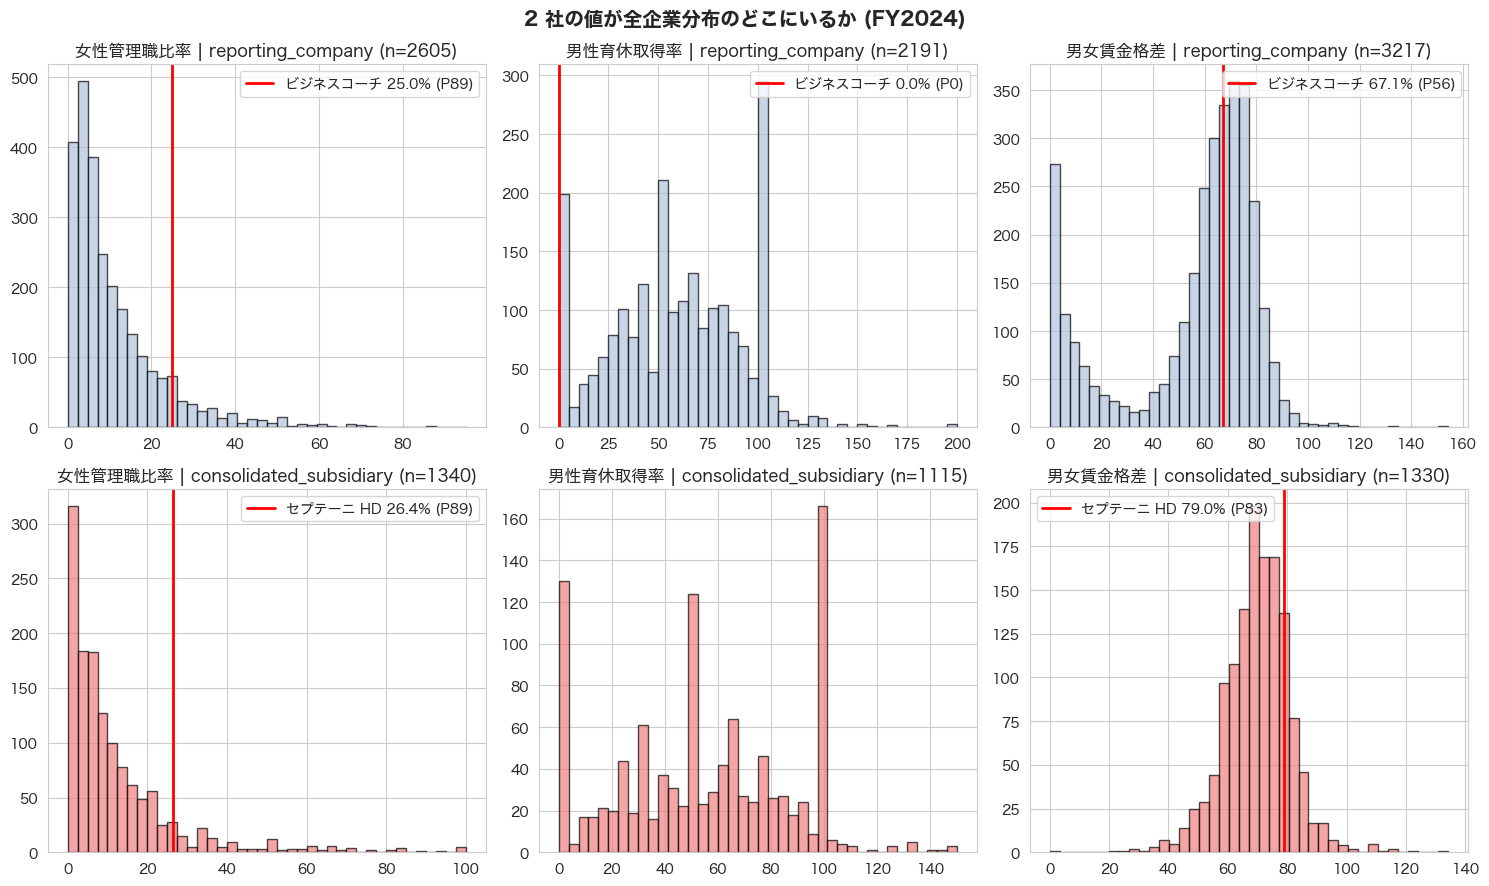

In [4]:
plt.rcParams['font.family'] = ['Hiragino Sans']  # 保険
def fetch_population(scope: str, worker_type: str, fiscal_year: int) -> pd.DataFrame:
    return conn.execute(
        """
        SELECT edinet_code, company_name, industry, employee_count,
               sales, operating_profit,
               female_manager_ratio, male_childcare_leave_ratio, gender_wage_gap
          FROM analytics.company_year_metrics
         WHERE scope = ? AND worker_type = ? AND fiscal_year = ?
        """,
        [scope, worker_type, fiscal_year],
    ).fetchdf()

rc_all = fetch_population('reporting_company', 'all', FY)
cs_all = fetch_population('consolidated_subsidiary', 'all', FY)

print(f'reporting_company × all (FY{FY}): n={len(rc_all)}')
print(f'consolidated_subsidiary × all (FY{FY}): n={len(cs_all)}')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f'2 社の値が全企業分布のどこにいるか (FY{FY})', fontsize=14, fontweight='bold')
for col_idx, metric in enumerate(HC_COLS):
    # 上段: reporting_company (ビジネスコーチが属する集団)
    ax = axes[0, col_idx]
    values = rc_all[metric].dropna().astype(float)
    ax.hist(values, bins=40, color='lightsteelblue', edgecolor='black', alpha=0.7)
    target = float(bcoach_row[metric]) if pd.notna(bcoach_row[metric]) else None
    if target is not None:
        pct = (values < target).mean() * 100
        ax.axvline(target, color='red', linewidth=2, label=f'ビジネスコーチ {target:.1f}% (P{pct:.0f})')
    ax.set_title(f'{HC_LABELS[metric]} | reporting_company (n={len(values)})')
    if ax.get_legend_handles_labels()[1]:
        ax.legend()

    # 下段: consolidated_subsidiary (セプテーニが属する集団)
    ax = axes[1, col_idx]
    values = cs_all[metric].dropna().astype(float)
    ax.hist(values, bins=40, color='lightcoral', edgecolor='black', alpha=0.7)
    target = float(septeni_row[metric]) if pd.notna(septeni_row[metric]) else None
    if target is not None:
        pct = (values < target).mean() * 100
        ax.axvline(target, color='red', linewidth=2, label=f'セプテーニ HD {target:.1f}% (P{pct:.0f})')
    ax.set_title(f'{HC_LABELS[metric]} | consolidated_subsidiary (n={len(values)})')
    if ax.get_legend_handles_labels()[1]:
        ax.legend()

plt.tight_layout()
plt.savefig('../artifacts/spotlight_01_overall_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. 業界 peer 比較

`companies.industry` は EDINETコード集約一覧から取り込む設計です。
未取得（NULL）の場合はこのセクションをスキップし、規模 peer (次セクション) に進みます。

In [5]:
industry_loaded = rc_all['industry'].notna().any() or cs_all['industry'].notna().any()
print(f'industry カラム充足: {industry_loaded}')

if not industry_loaded:
    print('⚠️ industry が未取得です。`edinet update-industries --source-file ...` の実行後にこのセクションを再実行してください。')
else:
    septeni_industry = septeni_row['industry']
    bcoach_industry = bcoach_row['industry']
    print(f'セプテーニ HD 業界: {septeni_industry}')
    print(f'ビジネスコーチ 業界: {bcoach_industry}')
    septeni_peers = cs_all[cs_all['industry'] == septeni_industry]
    bcoach_peers = rc_all[rc_all['industry'] == bcoach_industry]
    print(f'セプテーニ 業界 peer (連結): n={len(septeni_peers)}')
    print(f'ビジネスコーチ 業界 peer (単体): n={len(bcoach_peers)}')

industry カラム充足: True
セプテーニ HD 業界: サービス業
ビジネスコーチ 業界: サービス業
セプテーニ 業界 peer (連結): n=200
ビジネスコーチ 業界 peer (単体): n=667


## 5. 規模類似 peer 比較（対数スケール ±0.3 dex）

対数スケール ±0.3 dex は「規模が概ね半分から 2 倍まで」のレンジ。
ビジネスコーチ (58 名) なら 29-116 名、セプテーニ HD (1,800 名) なら 900-3,600 名が peer に含まれます。
線形 ±50% よりも統計的に妥当（企業規模分布は log-normal）。

セプテーニ HD (1800 名) 規模 peer (連結): n=516
ビジネスコーチ (58 名) 規模 peer (単体): n=490


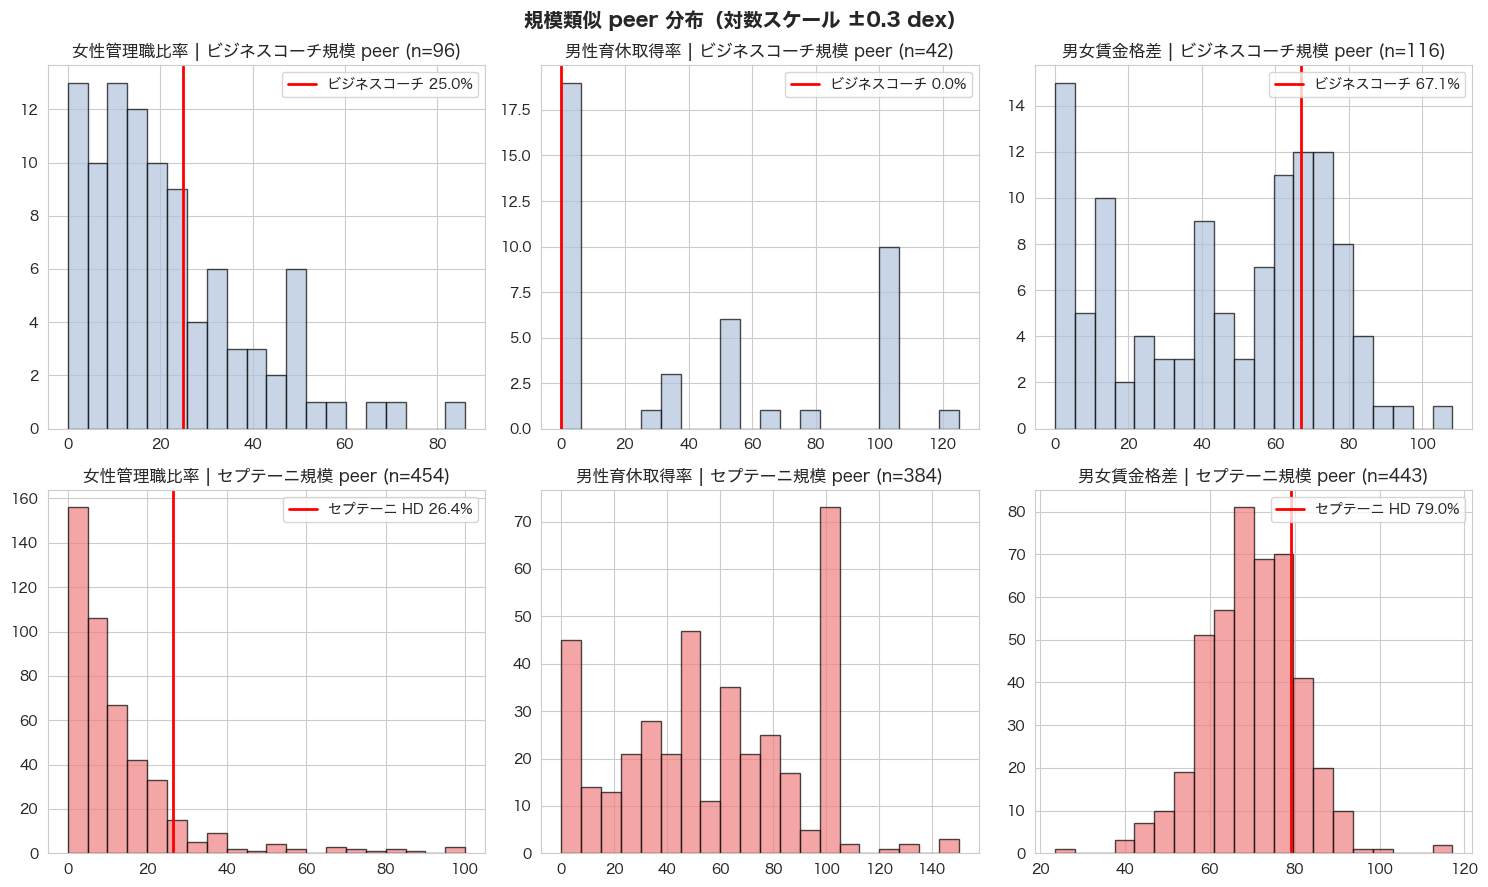

In [6]:
plt.rcParams['font.family'] = ['Hiragino Sans']  # 保険
def size_peers(pop: pd.DataFrame, target_employees: int, log_dex: float = 0.3) -> pd.DataFrame:
    target_log = np.log10(target_employees)
    df = pop.dropna(subset=['employee_count']).copy()
    df = df[df['employee_count'].astype(float) > 0]  # log10(0) = -inf を防ぐ
    df['log_emp'] = np.log10(df['employee_count'].astype(float))
    return df[(df['log_emp'] >= target_log - log_dex) & (df['log_emp'] <= target_log + log_dex)]

septeni_size_peers = size_peers(cs_all, int(septeni_row['employee_count']))
bcoach_size_peers = size_peers(rc_all, int(bcoach_row['employee_count']))

print(f'セプテーニ HD ({int(septeni_row["employee_count"])} 名) 規模 peer (連結): n={len(septeni_size_peers)}')
print(f'ビジネスコーチ ({int(bcoach_row["employee_count"])} 名) 規模 peer (単体): n={len(bcoach_size_peers)}')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('規模類似 peer 分布（対数スケール ±0.3 dex）', fontsize=14, fontweight='bold')
for col_idx, metric in enumerate(HC_COLS):
    # 上段: ビジネスコーチ
    ax = axes[0, col_idx]
    values = bcoach_size_peers[metric].dropna().astype(float)
    if not values.empty:
        ax.hist(values, bins=20, color='lightsteelblue', edgecolor='black', alpha=0.7)
    target = float(bcoach_row[metric]) if pd.notna(bcoach_row[metric]) else None
    if target is not None:
        ax.axvline(target, color='red', linewidth=2, label=f'ビジネスコーチ {target:.1f}%')
    ax.set_title(f'{HC_LABELS[metric]} | ビジネスコーチ規模 peer (n={len(values)})')
    if ax.get_legend_handles_labels()[1]:
        ax.legend()

    # 下段: セプテーニ
    ax = axes[1, col_idx]
    values = septeni_size_peers[metric].dropna().astype(float)
    if not values.empty:
        ax.hist(values, bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
    target = float(septeni_row[metric]) if pd.notna(septeni_row[metric]) else None
    if target is not None:
        ax.axvline(target, color='red', linewidth=2, label=f'セプテーニ HD {target:.1f}%')
    ax.set_title(f'{HC_LABELS[metric]} | セプテーニ規模 peer (n={len(values)})')
    if ax.get_legend_handles_labels()[1]:
        ax.legend()

plt.tight_layout()
plt.savefig('../artifacts/spotlight_02_size_peers.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. 「理想クラスタ」抽出

**理想クラスタ** = 3 HC 指標すべてが P75 以上 AND 営業利益率が P50 以上の企業群。
「**多様性と業績を両立した企業群**」の平均を「理想値」として提示します。

In [7]:
def ideal_cluster(pop: pd.DataFrame) -> pd.DataFrame:
    df = pop.copy()
    # NA-safe: pandas nullable Int64 由来の pd.NA を含む Series は
# np.where に渡すと 'boolean value of NA is ambiguous' になる。
# 一度 float に正規化してから比較する。
    sales_f = pd.to_numeric(df['sales'], errors='coerce')
    op_f = pd.to_numeric(df['operating_profit'], errors='coerce')
    df['op_margin'] = op_f / sales_f.where(sales_f > 0)
    thr = {
        'f': df['female_manager_ratio'].quantile(0.75),
        'm': df['male_childcare_leave_ratio'].quantile(0.75),
        'g': df['gender_wage_gap'].quantile(0.75),
        'op': df['op_margin'].quantile(0.50),
    }
    mask = (
        (df['female_manager_ratio'] >= thr['f'])
        & (df['male_childcare_leave_ratio'] >= thr['m'])
        & (df['gender_wage_gap'] >= thr['g'])
        & (df['op_margin'] >= thr['op'])
    )
    return df[mask], thr

rc_ideal, rc_thr = ideal_cluster(rc_all)
cs_ideal, cs_thr = ideal_cluster(cs_all)
print(f'reporting_company 理想クラスタ: n={len(rc_ideal)} (閾値 {rc_thr})')
print(f'consolidated_subsidiary 理想クラスタ: n={len(cs_ideal)} (閾値 {cs_thr})')
rc_ideal[['company_name', 'industry', 'employee_count'] + HC_COLS + ['op_margin']].head(15)

reporting_company 理想クラスタ: n=23 (閾値 {'f': np.float64(14.9), 'm': np.float64(85.7), 'g': np.float64(73.6), 'op': np.float64(0.055684370951053774)})
consolidated_subsidiary 理想クラスタ: n=14 (閾値 {'f': np.float64(15.8), 'm': np.float64(81.0), 'g': np.float64(76.9), 'op': np.float64(0.05968041706612254)})


,company_name,industry,employee_count,female_manager_ratio,male_childcare_leave_ratio,gender_wage_gap,op_margin
310,株式会社デサント,繊維製品,2659,25.00,100.0,104.40,0.068825
380,株式会社フジシールインターナショナル,その他製品,5692,40.00,100.0,77.80,0.067688
477,花王株式会社,化学,32566,27.70,96.8,90.50,0.090051
514,中外製薬株式会社,医薬品,7778,19.70,98.2,85.00,0.463008
586,メック株式会社,化学,480,26.32,90.0,87.14,0.250212
1572,ＪＢＣＣホールディングス株式会社,情報・通信業,1626,50.00,100.0,97.10,0.067828
1729,株式会社 丸井グループ,小売業,4290,22.40,100.0,77.80,0.174406
2162,株式会社ディア・ライフ,不動産業,643,25.00,100.0,88.40,0.098528
2563,株式会社ＮＴＴデータグループ,情報・通信業,193513,14.90,126.3,81.80,0.070878
2595,パーク二四株式会社（定款上の商号 パーク２４株式会社）,不動産業,5502,19.80,90.0,79.20,0.104329


## 7. 結論：4 種の「理想値」と現実的な道のり

業界 P75 / 規模 peer P75 / 理想クラスタ平均 / 業界トップ10 平均 を並べて 2 社の「目指すべき値」を提示します。

In [8]:
def build_ideal_table(target_row, size_peer_df, ideal_df, all_pop, industry):
    rows = []
    for metric in HC_COLS:
        current = float(target_row[metric]) if pd.notna(target_row[metric]) else None
        if industry and all_pop['industry'].notna().any():
            ind_pop = all_pop[all_pop['industry'] == industry][metric].dropna().astype(float)
        else:
            ind_pop = pd.Series([], dtype=float)
        size_pop = size_peer_df[metric].dropna().astype(float)
        ideal_pop = ideal_df[metric].dropna().astype(float)
        rows.append({
            '指標': HC_LABELS[metric],
            '現在値': current,
            '業界 P75': float(np.percentile(ind_pop, 75)) if len(ind_pop) >= 5 else np.nan,
            '規模 peer P75': float(np.percentile(size_pop, 75)) if len(size_pop) >= 5 else np.nan,
            '理想クラスタ平均': float(ideal_pop.mean()) if not ideal_pop.empty else np.nan,
            '業界トップ10 平均': float(ind_pop.nlargest(10).mean()) if len(ind_pop) >= 5 else np.nan,
        })
    return pd.DataFrame(rows)

print('### セプテーニ HD（連結子会社 scope）')
septeni_table = build_ideal_table(
    septeni_row, septeni_size_peers, cs_ideal, cs_all,
    industry=septeni_row.get('industry') if pd.notna(septeni_row.get('industry')) else None,
)
display(septeni_table)

print('\n### ビジネスコーチ（提出会社 scope）')
bcoach_table = build_ideal_table(
    bcoach_row, bcoach_size_peers, rc_ideal, rc_all,
    industry=bcoach_row.get('industry') if pd.notna(bcoach_row.get('industry')) else None,
)
display(bcoach_table)

### セプテーニ HD（連結子会社 scope）


,指標,現在値,業界 P75,規模 peer P75,理想クラスタ平均,業界トップ10 平均
0,女性管理職比率,26.4,29.20,16.05,33.289286,84.09
1,男性育休取得率,NaN,75.00,84.55,100.050000,102.50
2,男女賃金格差,79.0,82.15,77.40,84.592857,98.69



### ビジネスコーチ（提出会社 scope）


,指標,現在値,業界 P75,規模 peer P75,理想クラスタ平均,業界トップ10 平均
0,女性管理職比率,25.0,27.3,31.3275,29.179130,71.880
1,男性育休取得率,0.0,75.0,95.0000,103.569565,110.670
2,男女賃金格差,67.1,74.8,68.5250,83.297391,98.461


## 8. 半分冗談の処方箋

### セプテーニ HD（連結 1,800 名・広告マーケティング）
- 「**連結子会社の値**」が実体を表すこと、「**持株会社単体の値**」を見ても意味が無いことを利用者に伝えるのが先。
- グループ全体としての目標は、規模 peer (連結 1,000-3,600 名) の P75 を 1 年で 1〜2 ポイントずつ詰めるくらいが現実的。
- 「**理想クラスタ平均**」は連結 scope だと n が少なめになりがちなので、参考程度に。

### ビジネスコーチ（単体 58 名・コーチング/研修）
- 「**男性育休 0% → 3.3%**」の動き、規模 (58 名) で考えると **対象男性 0〜1 名のミクロケース**。 翌年度に 100% に飛んでも 0% に戻ってもおかしくない。
- **半分冗談で言うなら**: 目指すべきは「数値ではなく分母」。対象男性が 5 名以上いる規模になって初めて率の議論が意味を持つ。
- 女性管理職比率 25% → 20% は誤差レベル（管理職数自体が片手以下と推定）。 「**経営層・幹部の人数で語る**」のがフェア。

### メタな結論
比率指標は **n が小さい企業では情報を伝えない**。EDINET 開示制度は中堅企業の率公表を促しているが、統計的にはほぼノイズ。これは LT ネタにもなる「**比率を語る前に分母を語れ**」というメッセージ。